## 01: Import Libraries
We import all tools needed for HRV feature extraction.
- numpy and pandas: for data handling
- scipy: for signal processing and peak detection
- matplotlib: for plotting
- sklearn: for data preprocessing

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported")

All libraries imported


## 02: Load the Saved ECG Dataset
We load the segmented ECG windows and labels that we saved
on Day 2. Each row in X_ecg is one 30-second ECG window
with 7500 samples. y_labels contains 0 (normal) or 1 (apnea).

In [14]:
SAVE_PATH = r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman"

X_ecg = np.load(f"{SAVE_PATH}\\X_ecg.npy")
y = np.load(f"{SAVE_PATH}\\y_labels.npy")

print(f"Dataset loaded")
print(f"X_ecg shape : {X_ecg.shape}")
print(f"y shape     : {y.shape}")
print(f"Normal      : {np.sum(y==0)}")
print(f"Apnea       : {np.sum(y==1)}")

Dataset loaded
X_ecg shape : (2754, 7500)
y shape     : (2754,)
Normal      : 2389
Apnea       : 365


## 03: Extract HRV Features from One ECG Window
HRV (Heart Rate Variability) measures how much the time
between heartbeats changes. During apnea the heart rhythm
becomes irregular which shows up clearly in HRV features.
We extract these features for each 30-second ECG window:
- RR intervals: time between consecutive heartbeats
- SDNN: standard deviation of RR intervals
- RMSSD: root mean square of successive differences
- Mean HR: average heart rate in beats per minute
- pNN50: percentage of successive RR intervals differing by more than 50ms
- LF/HF ratio: low frequency to high frequency power ratio

In [15]:
def extract_hrv_features(ecg_window, fs=250):
    # Step 1: Detect R-peaks (heartbeat peaks)
    peaks, _ = find_peaks(ecg_window, distance=int(0.3*fs), height=np.mean(ecg_window))
    
    # Need at least 2 peaks to calculate RR intervals
    if len(peaks) < 2:
        return None
    
    # Step 2: Calculate RR intervals in milliseconds
    rr_intervals = np.diff(peaks) / fs * 1000  # convert to ms
    
    if len(rr_intervals) < 2:
        return None
    
    # Step 3: Time domain HRV features
    mean_rr   = np.mean(rr_intervals)
    sdnn      = np.std(rr_intervals)
    rmssd     = np.sqrt(np.mean(np.diff(rr_intervals)**2))
    mean_hr   = 60000 / mean_rr  # beats per minute
    pnn50     = np.sum(np.abs(np.diff(rr_intervals)) > 50) / len(rr_intervals) * 100
    
    # Step 4: Frequency domain features (LF/HF ratio)
    if len(rr_intervals) >= 4:
        freqs = np.fft.rfftfreq(len(rr_intervals), d=mean_rr/1000)
        power = np.abs(np.fft.rfft(rr_intervals))**2
        lf = np.sum(power[(freqs >= 0.04) & (freqs < 0.15)])
        hf = np.sum(power[(freqs >= 0.15) & (freqs < 0.4)])
        lf_hf = lf / hf if hf > 0 else 0
    else:
        lf_hf = 0
    
    return {
        'mean_rr': mean_rr,
        'sdnn': sdnn,
        'rmssd': rmssd,
        'mean_hr': mean_hr,
        'pnn50': pnn50,
        'lf_hf_ratio': lf_hf
    }

# Test on first window
features = extract_hrv_features(X_ecg[0], fs=250)
print("HRV features extracted from first window")
print(f"\nSample features:")
for key, val in features.items():
    print(f"  {key:15s}: {val:.4f}")

HRV features extracted from first window

Sample features:
  mean_rr        : 794.4865
  sdnn           : 221.6642
  rmssd          : 259.7606
  mean_hr        : 75.5205
  pnn50          : 37.8378
  lf_hf_ratio    : 1.0802


## 04: Extract HRV Features for All 2754 Windows
Now we apply the feature extraction function to every single
window in our dataset. This converts raw ECG signals into
a structured feature table ready for machine learning.
Windows where R-peaks cannot be detected are skipped.

In [16]:
all_features = []
valid_labels = []
skipped = 0

for i in range(len(X_ecg)):
    features = extract_hrv_features(X_ecg[i], fs=250)
    if features is not None:
        all_features.append(features)
        valid_labels.append(y[i])
    else:
        skipped += 1

# Convert to dataframe
df_features = pd.DataFrame(all_features)
df_features['label'] = valid_labels

print(f"Feature extraction complete!")
print(f"Total windows    : {len(X_ecg)}")
print(f"Valid windows    : {len(df_features)}")
print(f"Skipped windows  : {skipped}")
print(f"\nFeature table shape: {df_features.shape}")
print(f"\nFirst 5 rows:")
print(df_features.head())

Feature extraction complete!
Total windows    : 2754
Valid windows    : 2754
Skipped windows  : 0

Feature table shape: (2754, 7)

First 5 rows:
      mean_rr        sdnn       rmssd    mean_hr      pnn50  lf_hf_ratio  \
0  794.486486  221.664175  259.760574  75.520479  37.837838     1.080238   
1  862.823529  166.111315  182.822318  69.539133  29.411765     0.426120   
2  715.707317  257.865747  332.551951  83.833152  56.097561     0.114014   
3  782.842105  238.094025  296.033599  76.643808  42.105263     1.024932   
4  750.256410  255.073315  312.106594  79.972659  53.846154     0.957244   

   label  
0      1  
1      1  
2      1  
3      0  
4      0  


## 05: Visualize HRV Features — Apnea vs Normal
We plot the distribution of each HRV feature comparing
apnea windows vs normal windows. This shows us visually
which features are most useful for detecting apnea.
If the distributions are different — the feature is useful!

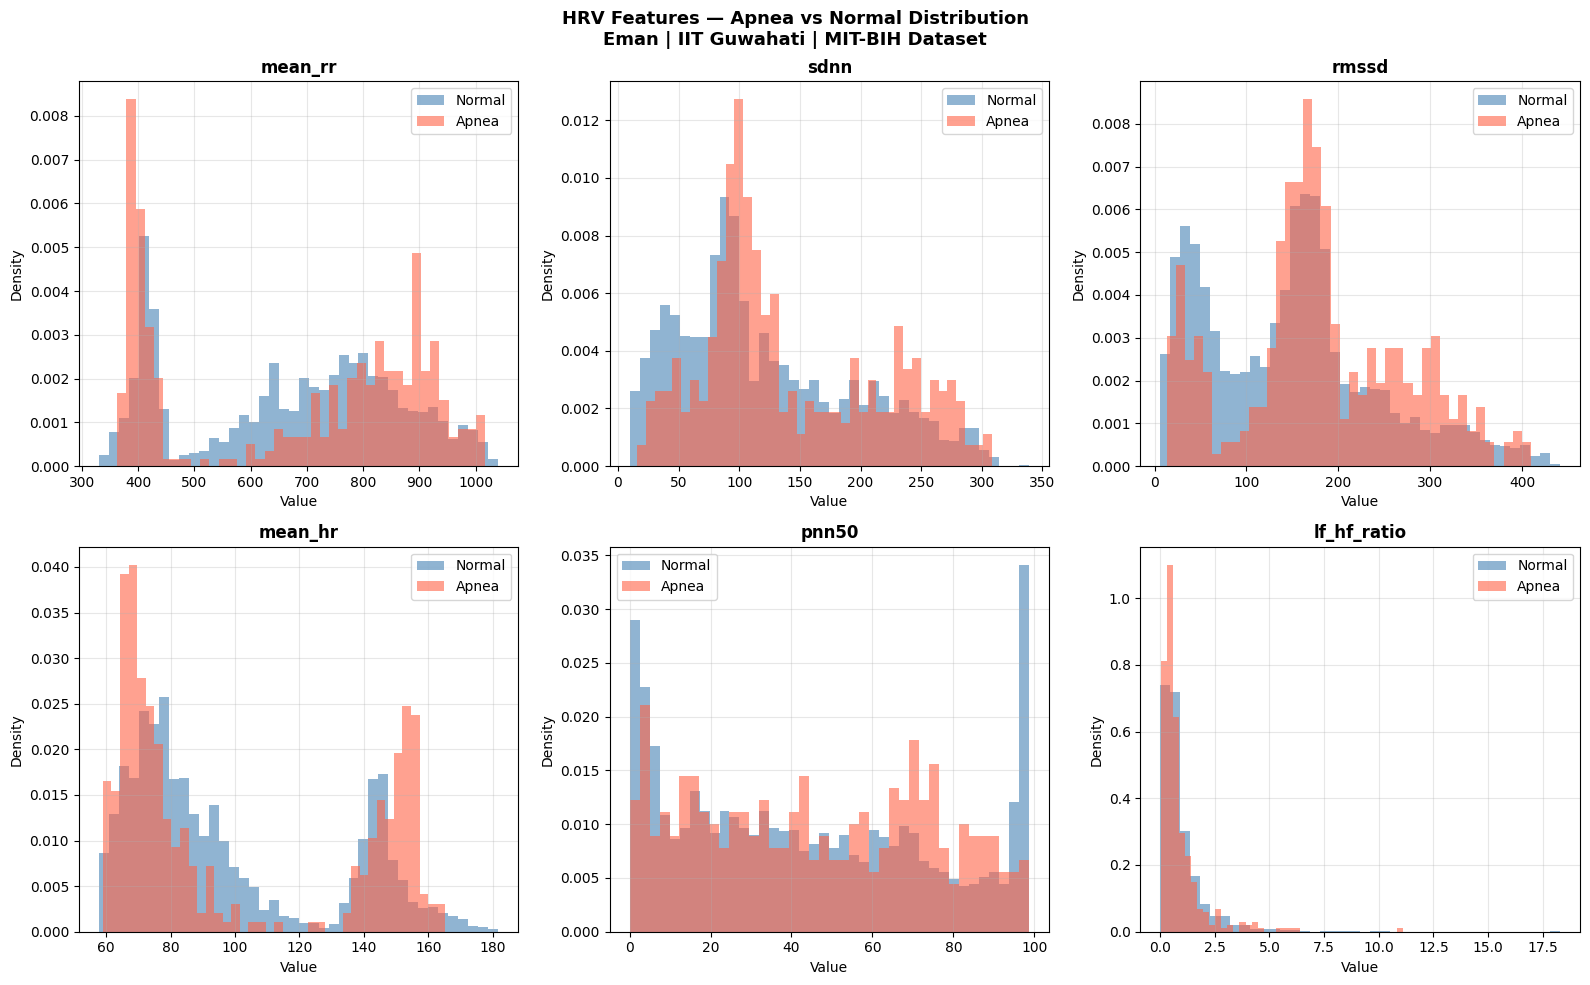

Plot saved


In [17]:
features_to_plot = ['mean_rr', 'sdnn', 'rmssd', 'mean_hr', 'pnn50', 'lf_hf_ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("HRV Features — Apnea vs Normal Distribution\nEman | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold')

normal_df = df_features[df_features['label'] == 0]
apnea_df  = df_features[df_features['label'] == 1]

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx // 3][idx % 3]
    ax.hist(normal_df[feat], bins=40, alpha=0.6, color='steelblue', label='Normal', density=True)
    ax.hist(apnea_df[feat],  bins=40, alpha=0.6, color='tomato',    label='Apnea',  density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman\ecg_hrv_features_plot.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 06: Save the HRV Feature Table
We save the complete feature table as a CSV file.
This file will be used when we merge ECG features
with EEG and respiratory features into one final table.

In [18]:
SAVE_PATH = r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman"

df_features.to_csv(f"{SAVE_PATH}\\ecg_hrv_features.csv", index=False)

print(f"Features saved")
print(f"File: ecg_hrv_features.csv")
print(f"Shape: {df_features.shape}")
print(f"\nColumns: {list(df_features.columns)}")

Features saved
File: ecg_hrv_features.csv
Shape: (2754, 7)

Columns: ['mean_rr', 'sdnn', 'rmssd', 'mean_hr', 'pnn50', 'lf_hf_ratio', 'label']
